### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs
#### Parte 4 - Identificando grupos relacionados ao câncer de mama

**Objetivo geral - Identificar características relevantes associadas a grupos relacionados ao câncer de mama.**

A investigação desta etapa utiliza técnicas de análise exploratória e agrupamento não supervisionado para observar padrões entre idade, raça/cor, nível de evidência de câncer de mama e outras variáveis da base tratada.

---

## Sumário da Parte 4

**Item 1 - Preparação da base e análise exploratória**

- **1.1 - Carregamento e amostra inicial**
- **1.2 - Descrição estatística inicial**
- **1.3 - Seleção das variáveis da base**
- **1.4 - Dimensões da base tratada**
- **1.5 - Interpretação dos níveis de câncer e da coluna `RACA_COR`**
- **1.6 - Distribuições gerais e por nível de câncer de mama**
- **1.7 - Boxplots, correlação e histogramas das variáveis**
- **1.8 - Criação da faixa de dias de internação**

**Item 2 - Agrupamento com KMeans**

- **2.1 - KMeans sem escalonamento para idade e raça/cor**
- **2.2 - Distribuição dos grupos e análise dos centróides**
- **2.3 - Método elbow e teste de diferentes valores de `k`**
- **2.4 - KMeans com escalonamento das variáveis**
- **2.5 - One-hot encoding de raça/cor e experimentos com PCA**

**Item 3 - Agrupamento com DBSCAN**

- **3.1 - Ajuste do DBSCAN para idade e raça/cor**
- **3.2 - Visualização dos agrupamentos identificados**
- **3.3 - Avaliação comparativa com silhouette score**

**Conclusão da Parte 4**

- **Síntese dos padrões encontrados na análise exploratória**
- **Comparação entre os principais resultados de KMeans e DBSCAN**
- **Interpretação final sobre o método mais adequado ao experimento**


#### Item 1 - Preparação da base e análise exploratória

**Neste passo vamos:**

- **1.1 - Carregar e visualizar uma amostra da base tratada** para confirmar o recorte utilizado na análise.
- **1.2 - Avaliar a descrição estatística geral** para entender escala, dispersão e possíveis extremos nas variáveis numéricas.
- **1.3 - Selecionar o conjunto de colunas utilizado** no experimento de agrupamento.
- **1.4 - Registrar as dimensões da base tratada** após o recorte das variáveis.
- **1.5 - Interpretar os níveis de câncer e a codificação de `RACA_COR`** para apoiar a leitura dos resultados.
- **1.6 - Visualizar distribuições gerais e por nível de câncer de mama** para identificar padrões demográficos.
- **1.7 - Inspecionar boxplots, correlação e histogramas** para observar concentração, dispersão e relações entre variáveis.
- **1.8 - Criar faixas de dias de internação** para complementar a análise descritiva.


##### 1.1 - Carregamento e amostra inicial

Leitura da base tratada gerada na parte 2 e visualização dos primeiros registros.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

dados_fase_1 = pd.read_parquet('2025_tratado.parquet')
dados_fase_1 = dados_fase_1[dados_fase_1["SEXO"] == "3"]
dados_fase_1 = dados_fase_1[dados_fase_1["CANCER_MAMA_NIVEL"]>0]

dados_fase_1.head()

,MES_CMPT,IDENT,MUNIC_RES,NASC,SEXO,COD_IDADE,IDADE,NUM_FILHOS,INSTRU,GESTRISCO,CONTRACEP1,CONTRACEP2,RACA_COR,MUNIC_MOV,DT_INTER,DT_SAIDA,DIAS_PERM,QT_DIARIAS,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,MORTE,PROC_REA,DIAG_PRINC,DIAG_SECUN,CID_NOTIF,CID_ASSO,CID_MORTE,DIAGSEC1,DIAGSEC2,DIAGSEC3,DIAGSEC4,DIAGSEC5,DIAGSEC6,DIAGSEC7,DIAGSEC8,DIAGSEC9,TPDISEC1,TPDISEC2,TPDISEC3,TPDISEC4,TPDISEC5,TPDISEC6,TPDISEC7,TPDISEC8,TPDISEC9,COMPLEX,VAL_TOT,DIAR_ACOM,NASC_DT,ANO_NASC,IDADE_ANOS,DIAG_SECUN_VALIDA,DIAG_PRINC_INT,DIAG_SECUN_INT,CID_ASSO_INT,CID_NOTIF_INT,DIAGSEC1_INT,DIAGSEC2_INT,DIAGSEC3_INT,DIAGSEC4_INT,DIAGSEC5_INT,DIAGSEC6_INT,DIAGSEC7_INT,DIAGSEC8_INT,DIAGSEC9_INT,CID_MORTE_INT,DIAG_PRINC_GRUPO,VIOLENCIA_MULHER_NIVEL,CANCER_MAMA_NIVEL
3042,01,1,330120,19820825,3,4,42,0,0,1,00,00,02,330580,20250113,20250128,15,15,0,0,0,0,0,0,0,0,0,0303060298,C509,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,686.30,15,1982-08-25,1982,42,False,3509,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,3
3044,01,1,330580,19621010,3,4,62,0,0,1,00,00,01,330580,20250114,20250122,8,9,0,0,0,0,0,0,0,0,0,0304100021,C509,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,02,906.55,9,1962-10-10,1962,62,False,3509,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,3
4721,01,1,330510,19810406,3,4,43,0,0,1,00,00,02,330455,20250128,20250130,2,2,0,0,0,0,0,0,0,0,0,0415020050,C509,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,03,3492.67,1,1981-04-06,1981,43,False,3509,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,3
4722,01,1,330414,19790527,3,4,45,0,0,1,00,00,03,330455,20250128,20250130,2,2,0,0,0,0,0,0,0,0,0,0415020050,C509,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,03,3445.54,1,1979-05-27,1979,45,False,3509,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,3
4723,01,1,330350,19540514,3,4,70,0,0,1,00,00,03,330455,20250128,20250130,2,2,0,0,0,0,0,0,0,0,0,0415020050,C509,0000,,0000,0000,,,,,,,,,,0,0,0,0,0,0,0,0,0,03,3363.98,1,1954-05-14,1954,70,False,3509,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,3


##### 1.2 - Descrição estatística inicial

Resumo estatístico das colunas numéricas para observar escala, dispersão e possíveis valores extremos.

In [2]:
dados_fase_1.describe()

,IDADE,NUM_FILHOS,DIAS_PERM,QT_DIARIAS,UTI_MES_IN,UTI_MES_AN,UTI_MES_AL,UTI_MES_TO,UTI_INT_IN,UTI_INT_AN,UTI_INT_AL,UTI_INT_TO,MORTE,VAL_TOT,DIAR_ACOM,NASC_DT,ANO_NASC,IDADE_ANOS,DIAG_PRINC_INT,DIAG_SECUN_INT,CID_ASSO_INT,CID_NOTIF_INT,DIAGSEC1_INT,DIAGSEC2_INT,DIAGSEC3_INT,DIAGSEC4_INT,DIAGSEC5_INT,DIAGSEC6_INT,DIAGSEC7_INT,DIAGSEC8_INT,DIAGSEC9_INT,CID_MORTE_INT,DIAG_PRINC_GRUPO,VIOLENCIA_MULHER_NIVEL,CANCER_MAMA_NIVEL
count,9037.000000,9037.0,9037.000000,9037.000000,9037.0,9037.0,9037.0,9037.000000,9037.0,9037.0,9037.0,9037.0,9037.000000,9037.000000,9037.000000,9037,9037.000000,9037.000000,9037.000000,9037.0,9037.0,9037.0,9037.000000,9037.000000,9037.000000,9037.000000,9037.000000,9037.000000,9037.000000,9037.000000,9037.0,9037.0,9037.000000,9037.000000,9037.000000
mean,57.051455,0.0,3.780347,3.735089,0.0,0.0,0.0,0.187230,0.0,0.0,0.0,0.0,0.098705,2002.737902,1.091513,1967-11-27 15:22:55.544982,1967.414739,57.068275,3855.284276,0.0,0.0,0.0,504.073586,271.630962,208.264911,106.860795,53.622662,23.616687,3.363174,2.966471,0.0,0.0,3.022021,0.002545,2.781897
min,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,40.380000,0.000000,1922-02-09 00:00:00,1922.000000,0.000000,109.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,1.000000
25%,48.000000,0.0,1.000000,1.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,426.120000,0.000000,1957-12-25 00:00:00,1957.000000,48.000000,3508.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,2.000000,0.000000,3.000000
50%,57.000000,0.0,2.000000,2.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,1314.950000,0.000000,1967-07-11 00:00:00,1967.000000,57.000000,3509.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,2.000000,0.000000,3.000000
75%,67.000000,0.0,4.000000,4.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,3004.190000,1.000000,1977-06-17 00:00:00,1977.000000,67.000000,3509.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,2.000000,0.000000,3.000000
max,98.000000,0.0,116.000000,116.000000,0.0,0.0,0.0,52.000000,0.0,0.0,0.0,0.0,1.000000,45989.550000,116.000000,2025-05-27 00:00:00,2025.000000,100.000000,26853.000000,0.0,0.0,0.0,26952.000000,26924.000000,26950.000000,26924.000000,26931.000000,26824.000000,26833.000000,26808.000000,0.0,0.0,16.000000,1.000000,3.000000
std,14.261917,0.0,5.469512,5.277469,0.0,0.0,0.0,1.400421,0.0,0.0,0.0,0.0,0.298282,2417.812371,3.189724,NaN,14.269305,14.268914,3008.508071,0.0,0.0,0.0,2978.058346,2337.874573,2143.963644,1554.125961,1130.126435,757.031505,283.130172,282.002055,0.0,0.0,2.846808,0.050387,0.608076


##### 1.3 - Seleção das variáveis da base

Recorte das colunas utilizadas no experimento de agrupamento.


In [ ]:
dados_fase_1 = dados_fase_1[[
    "UTI_MES_TO",
    "DIAS_PERM",
    "QT_DIARIAS",
    "DIAR_ACOM",
    "IDADE_ANOS",
    "COMPLEX",
    "MES_CMPT",
    "RACA_COR",
    "MORTE",
    "CANCER_MAMA_NIVEL",
    "PROC_REA",
    "MUNIC_RES",
    "MUNIC_MOV",
    "DIAG_PRINC_INT",
    ]]

dados_fase_1["COMPLEX_INT"] = dados_fase_1["COMPLEX"].astype(int)
dados_fase_1["MES_CMPT"] = dados_fase_1["MES_CMPT"].astype(int)
dados_fase_1["PROC_REA"] =  dados_fase_1["PROC_REA"].str[:2].astype(int)
dados_fase_1["RACA_COR"] =  dados_fase_1["RACA_COR"].astype(int)


##### 1.4 - Dimensões da base tratada

Conferência da quantidade de linhas e colunas disponíveis para a modelagem.

In [4]:
dados_fase_1.shape

(9037, 16)

##### 1.5 - Interpretação dos níveis de câncer e da coluna `RACA_COR`

**Níveis de câncer de mama**
- **0 - Sem indício**
- **1 - Possível:** sintomas relacionados à mama
- **2 - Provável**
- **3 - Confirmado**

**Codificação de raça/cor do paciente**
- **1 - Branca**
- **2 - Preta**
- **3 - Parda**
- **4 - Amarela**
- **5 - Indígena**
- **99 - Sem informação**

##### 1.6 - Distribuições gerais e por nível de câncer de mama

Função auxiliar e geração de gráficos para analisar padrões demográficos na base geral e nos subconjuntos por nível.


In [7]:
def exibir_distribuicoes_dados_pessoais(titulo, dados, geral:bool = True):
    fig, axs = plt.subplots(3, 2, figsize=(13, 15)) if geral else plt.subplots(2, 2, figsize=(13, 10))

    
    dist_por_faixa_dade = axs[0][1] if geral else axs[0][0]
    raca_cor_amostra = axs[1][0] if geral else axs[0][1]    
    dist_mes = axs[2][0] if geral else axs[1][0]
    dist_por_casos_obito = axs[2][1] if geral else axs[1][1]

    if (geral):
        dist_por_nivel = axs[0][0]
        dist_por_nivel.set_title("Distribuição por Nível")
        dist_por_nivel.set_xticklabels(
        ["Possível", "Provável", "Confirmado"]
        )
        dist_por_nivel.set_ylabel("Quantidade de Casos")
        dist_por_nivel.set_xlabel("Nível")
        sb.countplot(x = dados["CANCER_MAMA_NIVEL"], ax = dist_por_nivel)

    dist_por_faixa_dade.set_title("Distribuição por Faixa de Idade")
    dist_por_faixa_dade.set_ylabel("Quantidade de Casos")
    dist_por_faixa_dade.set_xlabel("Faixa de Idade")
    sb.countplot(x = dados["fx_idade"], ax = dist_por_faixa_dade)

    raca_cor_amostra.set_xticklabels(
    ["Preta", "Branca", "Parda", "Amarela", "Indígena" ]
    )

    raca_cor_amostra.set_title("Distribuição por raça/cor - Dados")
    raca_cor_amostra.set_ylabel("Percentual (%)")
    raca_cor_amostra.set_xlabel("Raça/Cor")
    sb.countplot(x = dados["RACA_COR"], ax = raca_cor_amostra, stat='percent')

    dados1 = {
        "Codigo": [1, 2, 3, 4, 5],
        "Raca_Cor": ["Branca", "Preta", "Parda", "Amarela", "Indígena"],
        "Percentual": [42.0, 16.2, 41.6, 0.14, 0.10]
    }

    df = pd.DataFrame(dados1)

    if (geral):
        raca_cor_rj_ibge_2022 = axs[1][1]
        raca_cor_rj_ibge_2022 = sb.barplot(data=df, x="Raca_Cor", y="Percentual", ax=raca_cor_rj_ibge_2022)

        for i, v in enumerate(df["Percentual"]):
            raca_cor_rj_ibge_2022.text(i, v + 0.5, f"{v}%", ha='center')

        raca_cor_rj_ibge_2022.set_title("Distribuição por raça/cor - UF RJ (IBGE 2022)")
        raca_cor_rj_ibge_2022.set_ylabel("Percentual (%)")
        raca_cor_rj_ibge_2022.set_xlabel("Raça/Cor")
        raca_cor_rj_ibge_2022.set_ylim(0, 50)

    dist_mes.set_title("Distribuição por mês")
    dist_mes.set_ylabel("Quantidade de Casos")
    dist_mes.set_xlabel("Mês")
    sb.countplot(x = dados["MES_CMPT"], ax = dist_mes)

    dist_por_casos_obito.set_title("Ocorrência de Óbito")
    dist_por_casos_obito.set_ylabel("Quantidade de Casos")
    dist_por_casos_obito.set_xlabel("0 - Não / 1 - Sim")
    sb.countplot(x = dados["MORTE"], ax = dist_por_casos_obito)

    fig.suptitle(titulo, fontsize=18)

    plt.tight_layout()

    plt.show()

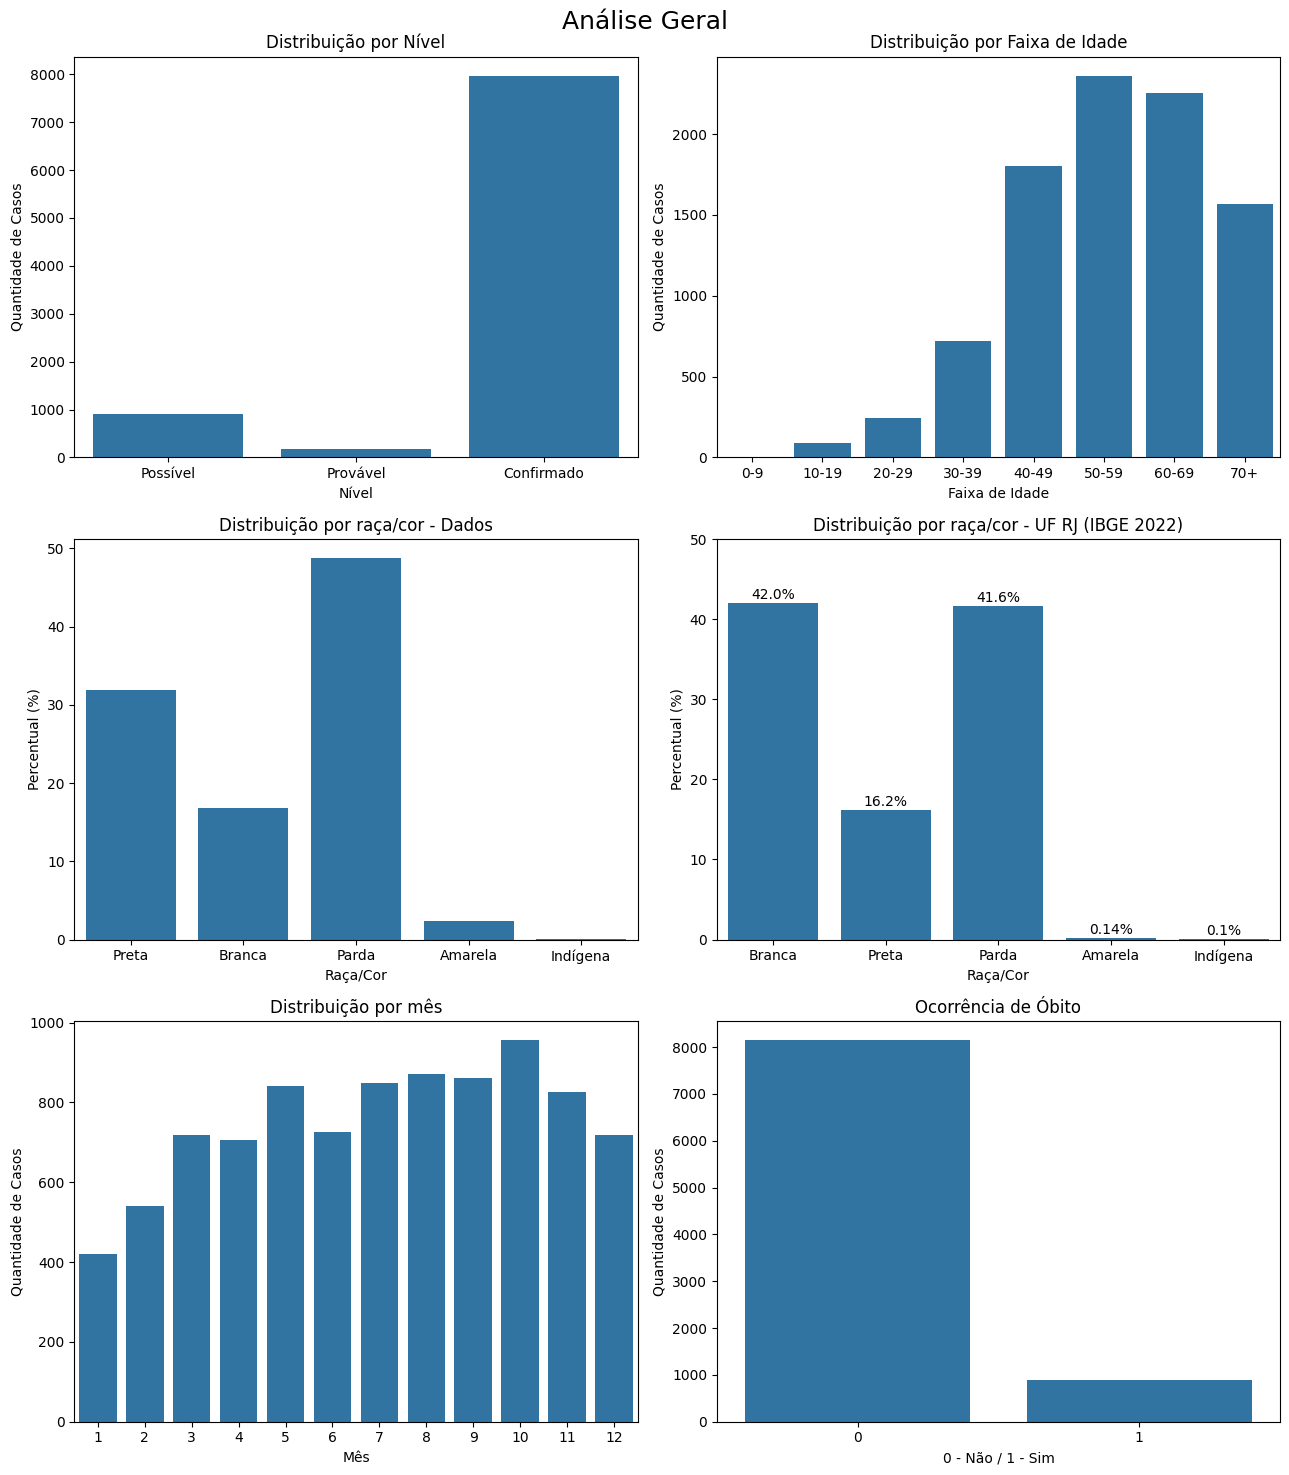

In [8]:
exibir_distribuicoes_dados_pessoais("Análise Geral", dados_fase_1)    

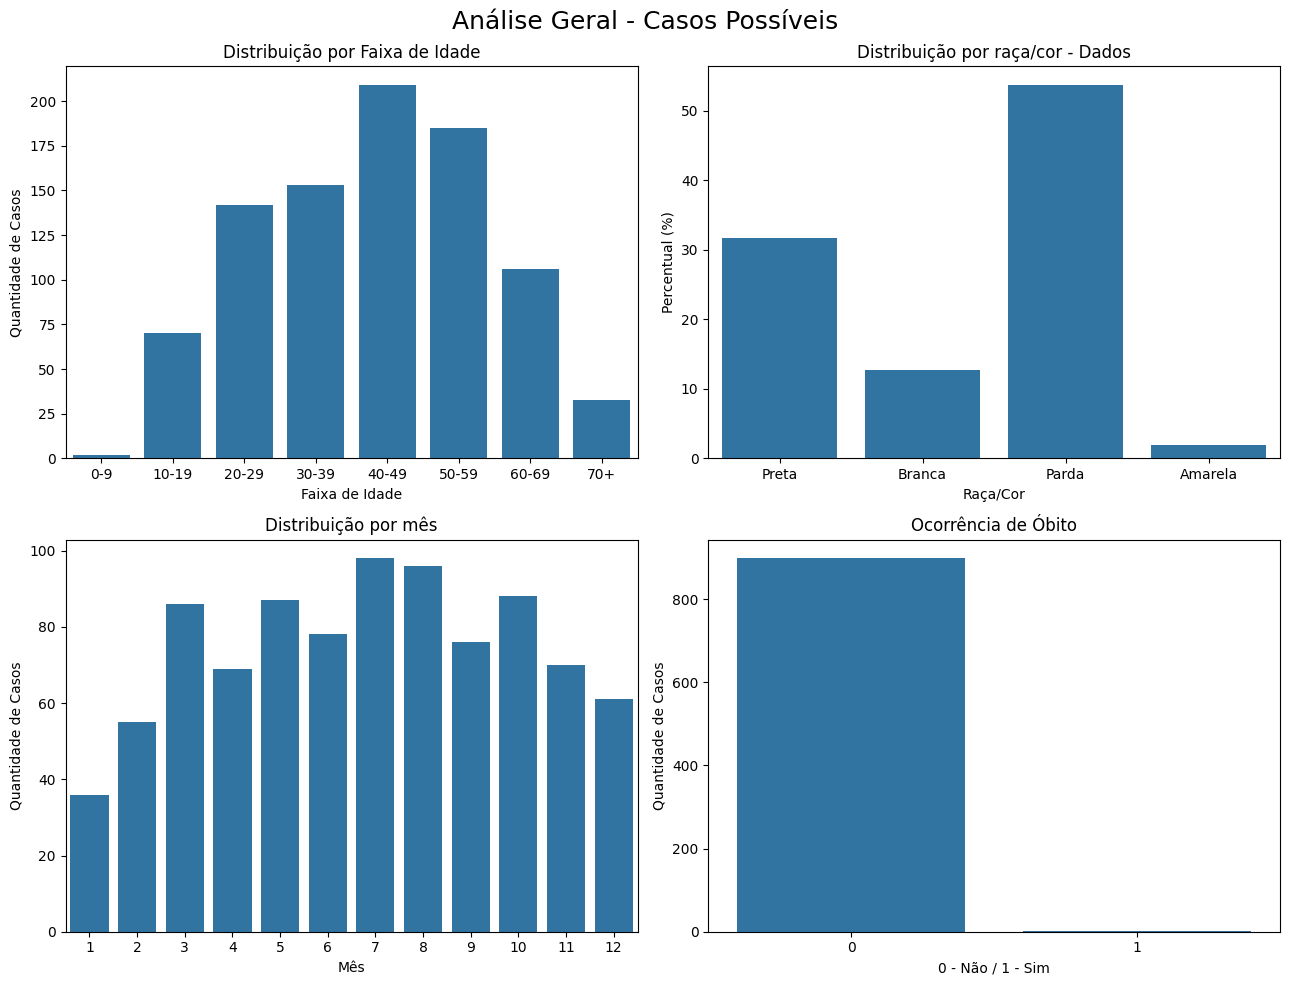

In [9]:
exibir_distribuicoes_dados_pessoais("Análise Geral - Casos Possíveis", dados_fase_1[dados_fase_1["CANCER_MAMA_NIVEL"] == 1], geral=False)

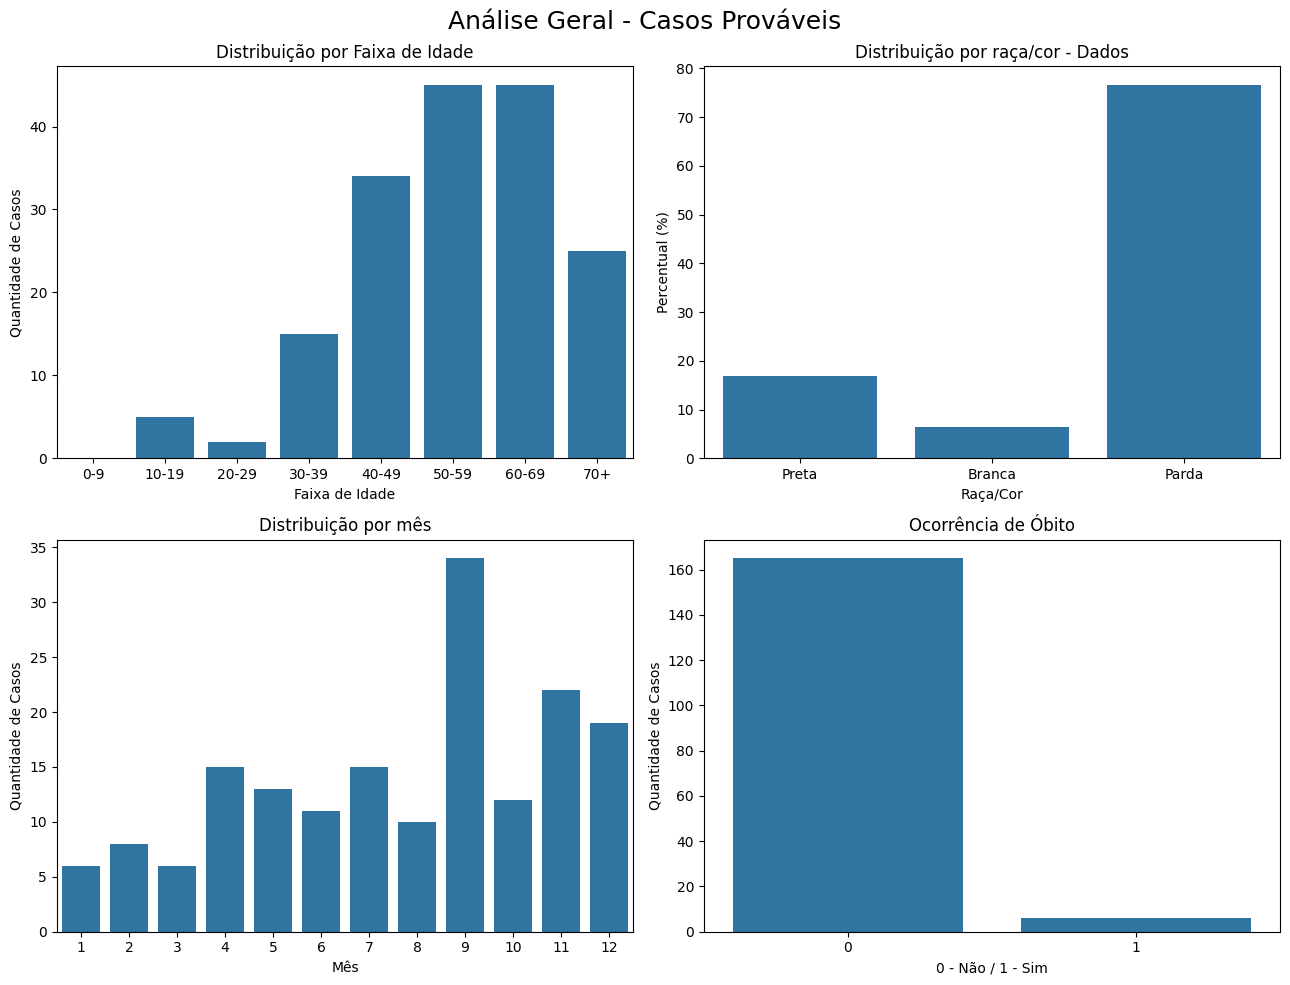

In [10]:
exibir_distribuicoes_dados_pessoais("Análise Geral - Casos Prováveis", dados_fase_1[dados_fase_1["CANCER_MAMA_NIVEL"] == 2], geral=False)

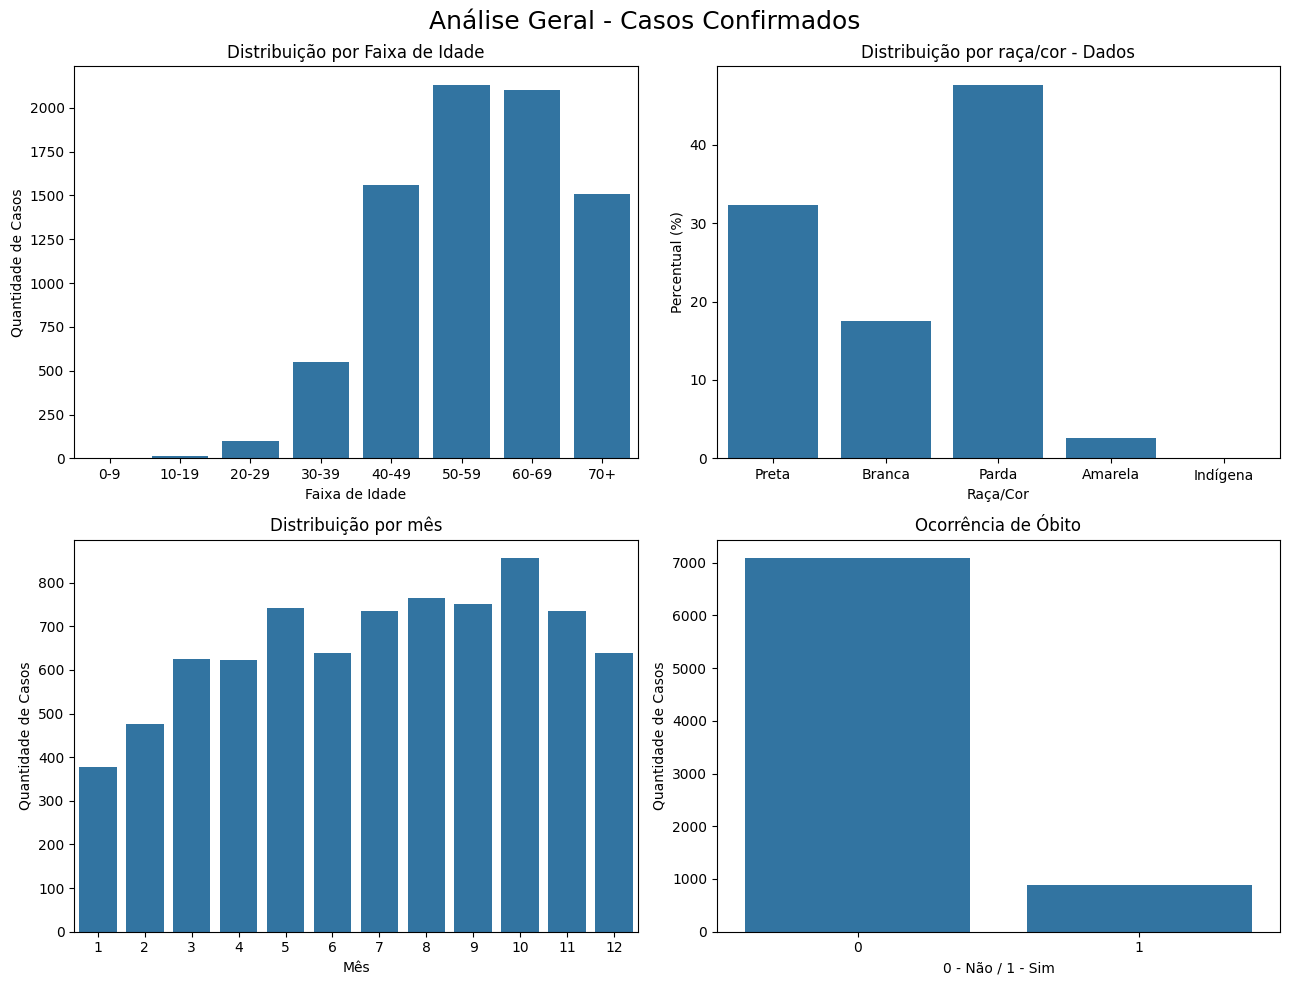

In [11]:
exibir_distribuicoes_dados_pessoais("Análise Geral - Casos Confirmados", dados_fase_1[dados_fase_1["CANCER_MAMA_NIVEL"] == 3], geral=False)

##### 1.7 - Boxplots, correlação e histogramas das variáveis

Visualizações para inspecionar dispersão, assimetria e relação entre idade, raça/cor, permanência e nível de câncer de mama.


<Axes: ylabel='IDADE_ANOS'>

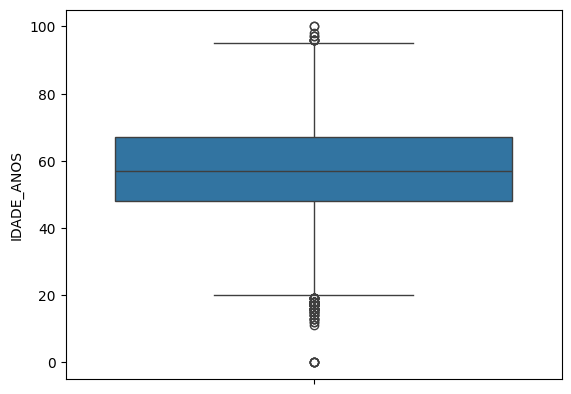

In [12]:
sb.boxplot(y=dados_fase_1["IDADE_ANOS"])

<Axes: ylabel='fx_idade'>

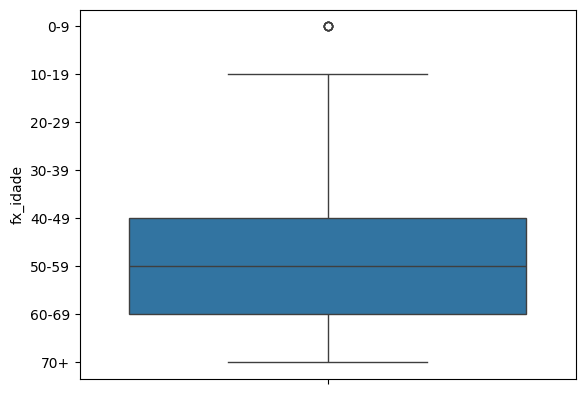

In [13]:
sb.boxplot(y=dados_fase_1["fx_idade"])

<Axes: >

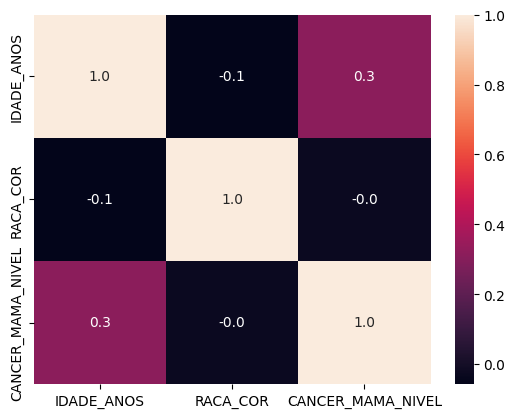

In [14]:
sb.heatmap(dados_fase_1[['IDADE_ANOS', 'RACA_COR', 'CANCER_MAMA_NIVEL']].corr(method = 'pearson'), annot=True, fmt=".1f")

array([[<Axes: title={'center': 'UTI_MES_TO'}>,
        <Axes: title={'center': 'DIAS_PERM'}>,
        <Axes: title={'center': 'QT_DIARIAS'}>,
        <Axes: title={'center': 'DIAR_ACOM'}>],
       [<Axes: title={'center': 'IDADE_ANOS'}>,
        <Axes: title={'center': 'MES_CMPT'}>,
        <Axes: title={'center': 'RACA_COR'}>,
        <Axes: title={'center': 'MORTE'}>],
       [<Axes: title={'center': 'CANCER_MAMA_NIVEL'}>,
        <Axes: title={'center': 'PROC_REA'}>,
        <Axes: title={'center': 'DIAG_PRINC_INT'}>,
        <Axes: title={'center': 'COMPLEX_INT'}>],
       [<Axes: title={'center': 'houve_deslocamento'}>,
        <Axes: title={'center': 'fx_idade_enc'}>, <Axes: >, <Axes: >]],
      dtype=object)

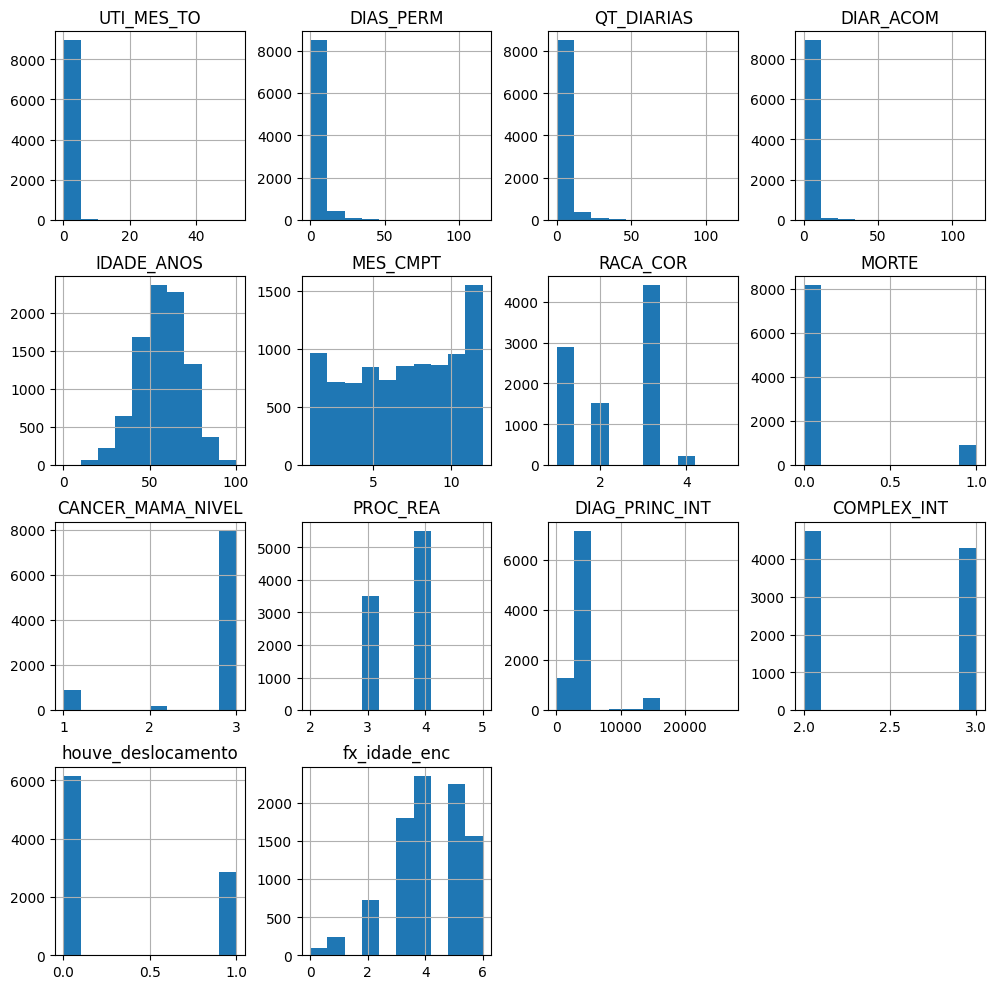

In [15]:
dados_fase_1.hist(figsize=(12,12))

<Axes: xlabel='DIAS_PERM', ylabel='Count'>

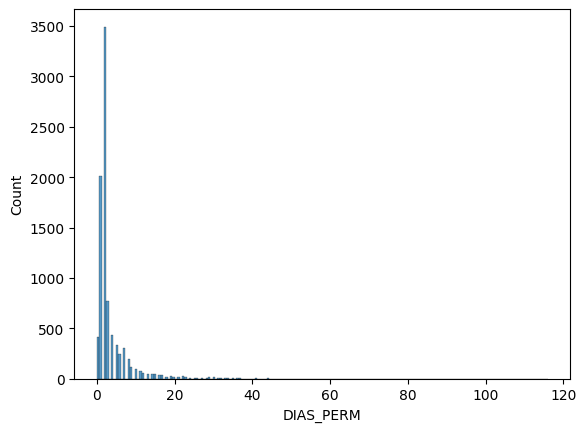

In [16]:
sb.histplot(dados_fase_1["DIAS_PERM"])

##### 1.8 - Criação da faixa de dias de internação

Construção de faixas para `DIAS_PERM` como apoio à análise descritiva da permanência hospitalar.


<Axes: xlabel='fx_dias_inter_enc', ylabel='Count'>

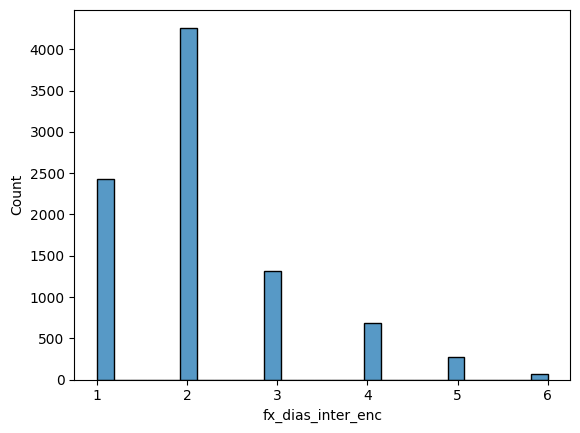

In [17]:
bins = [0, 1, 3, 7, 15, 30, np.inf]
mapa = {
    "0-1 (curtíssima)": 1,
    "2-3 (curta)": 2,
    "4-7 (moderada)": 3,
    "8-15 (prolongada)": 4,
    "16-30 (longa)": 5,
    "30+ (muito longa)": 6
}

def faixa_dias_inter_label_enc(df):
    df["fx_dias_inter"] = pd.cut(
        df["DIAS_PERM"],
        bins=bins,
        labels=mapa.keys(),
        include_lowest=True
    )
    df["fx_dias_inter_enc"] = df["fx_dias_inter"].map(mapa)
    df["fx_dias_inter_enc"] = df["fx_dias_inter_enc"].astype(int)
    return df
    #return df.drop(columns=["DIAS_PERM", "fx_dias_inter"])  
dados_fase_1 = faixa_dias_inter_label_enc(dados_fase_1)
sb.histplot(dados_fase_1["fx_dias_inter_enc"])

In [18]:
dados_fase_1.describe()
dados_fase_1 = dados_fase_1.drop(columns=["fx_idade_enc","fx_dias_inter_enc"])

#### Item 2 - Agrupamento com KMeans

**Neste passo vamos:**

- **2.1 - Ajustar um KMeans sem escalonamento** usando `IDADE_ANOS` e `RACA_COR` como variáveis de agrupamento.
- **2.2 - Inspecionar a distribuição dos grupos e os centróides** para entender como os clusters foram formados.
- **2.3 - Aplicar o método elbow e testar diferentes valores de `k`** para observar a estabilidade inicial dos agrupamentos.
- **2.4 - Repetir o experimento com padronização** para reduzir o efeito da diferença de escala entre as variáveis.
- **2.5 - Aplicar one-hot encoding em `RACA_COR`, usar `PCA` e reexecutar o `KMeans`** para avaliar ganhos de separação.


##### 2.1 - KMeans sem escalonamento para idade e raça/cor

Primeiro experimento de clusterização usando apenas `IDADE_ANOS` e `RACA_COR`.


##### GRUPOS #####
2    1904
1    1765
5    1679
0    1338
7     841
4     830
3     485
6     195
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[47.132287    2.28026906]
 [69.9898017   2.18526912]
 [61.55252101  2.19852941]
 [32.3257732   2.33608247]
 [81.52289157  2.09277108]
 [53.96664681  2.23645027]
 [20.27692308  2.35384615]
 [40.46254459  2.21165279]]
##################
 
##### SILHOUETE SCORE #####
0.47467394951969377
##################


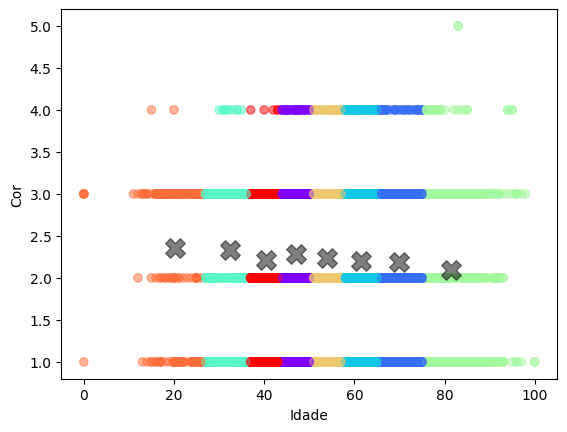

In [20]:
def executar_kmeans(dados, clusters, colunas, exibir_grafico = True):
    kmeans = KMeans(n_clusters = clusters,random_state=0) #definindo os hiperparametros do algoritmo (definir o número de grupo = cluster)

    #Implementando o K-Means nos dados:
    kmeans.fit(dados)

    #Salvando os centroides de cada cluster
    centroides = kmeans.cluster_centers_

    #Salvando os labels dos clusters para cada exemplo
    kmeans_labels = kmeans.predict(dados)

    dados['Grupos'] = kmeans_labels

    print("##### GRUPOS #####")
    print(pd.Series(kmeans_labels).value_counts())
    print("##################")
    print(" ")
    print("##### CENTROIDES #####")
    print(centroides)
    print("##################")
    print(" ")
    print("##### SILHOUETE SCORE #####")
    print(silhouette_score(dados[[colunas[0], colunas[1]]], kmeans_labels))
    print("##################")

    if(exibir_grafico):
        plt.scatter(dados[colunas[0]], dados[colunas[1]], c=kmeans_labels, alpha=0.5, cmap='rainbow')
        plt.xlabel('Idade')
        plt.ylabel('Cor')

        # plotando os centroides
        plt.scatter(centroides[:, 0], centroides[:, 1], c='black', marker='X', s=200, alpha=0.5)
        plt.rcParams['figure.figsize'] = (10, 5)
        plt.show()

    


executar_kmeans(dados_fase_1[['IDADE_ANOS', 'RACA_COR']], 8, ['IDADE_ANOS', 'RACA_COR'])



##### 2.2 - Distribuição dos grupos e análise dos centróides

Inspeção do tamanho dos clusters, dos centróides encontrados e da dispersão visual dos grupos gerados sem escalonamento.


##### 2.3 - Método elbow para definição inicial de `k`

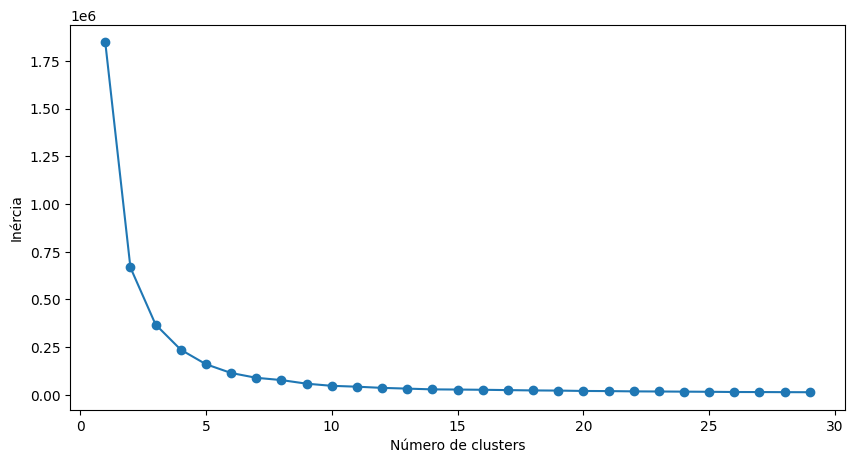

In [21]:
def aplicar_elbow(dados, colunas, limite):
    sse = []
    k = range(1,limite)
    for i in k:
        kmeans = KMeans(n_clusters=i, random_state=0)
        kmeans.fit(dados[colunas])
        sse.append(kmeans.inertia_) #calculo do erro do k-mens (mudar o centroide dos dados)

    plt.rcParams['figure.figsize'] = (10, 5)
    # Plota o gráfico com a soma dos erros quadraticos
    plt.plot(k, sse, '-o')
    plt.xlabel(r'Número de clusters')
    plt.ylabel('Inércia')
    plt.show()

aplicar_elbow(dados_fase_1, ['IDADE_ANOS','RACA_COR'], 30)

Primeiro, aplicamos o método elbow com um limite mais alto para observar a estabilização da **inércia**. Em seguida, refinamos a análise com um intervalo menor, limitado a **10 grupos**, para identificar com mais clareza o ponto de inflexão.

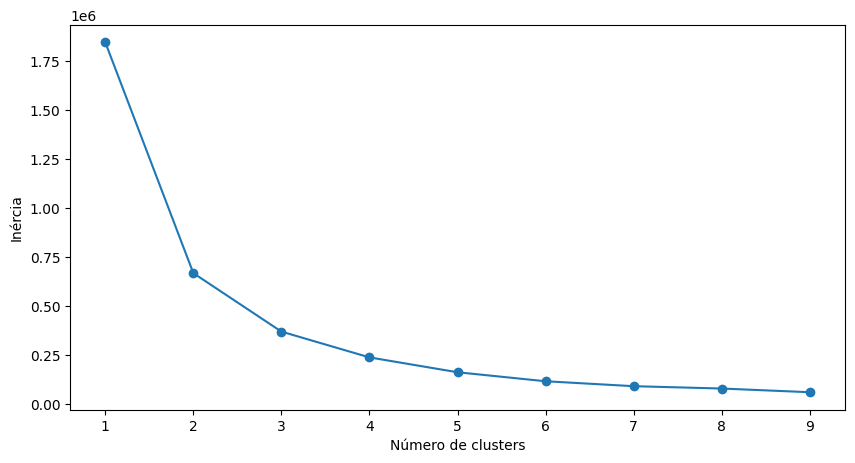

In [22]:
aplicar_elbow(dados_fase_1, ['IDADE_ANOS','RACA_COR'], 10)

Com base no comportamento do gráfico, testamos em seguida soluções com **3** e **4 clusters** para comparar a separação obtida.

##### GRUPOS #####
2    4027
0    2637
1    2373
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[40.05460751  2.27455442]
 [74.39696587  2.14917826]
 [57.99801341  2.2200149 ]]
##################
 
##### SILHOUETE SCORE #####
0.5077484866608012
##################


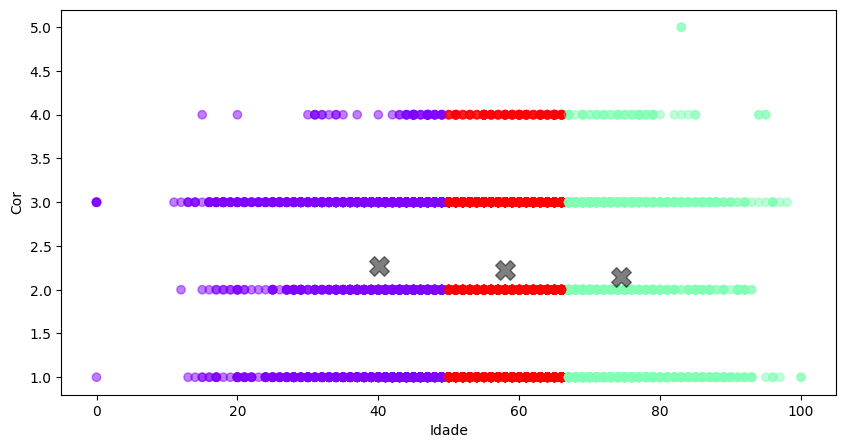

In [23]:
executar_kmeans(dados_fase_1[['IDADE_ANOS', 'RACA_COR']], 3, ['IDADE_ANOS', 'RACA_COR'])

##### GRUPOS #####
2    4027
0    2637
1    2373
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[40.05460751  2.27455442]
 [74.39696587  2.14917826]
 [57.99801341  2.2200149 ]]
##################
 
##### SILHOUETE SCORE #####
0.5077484866608012
##################


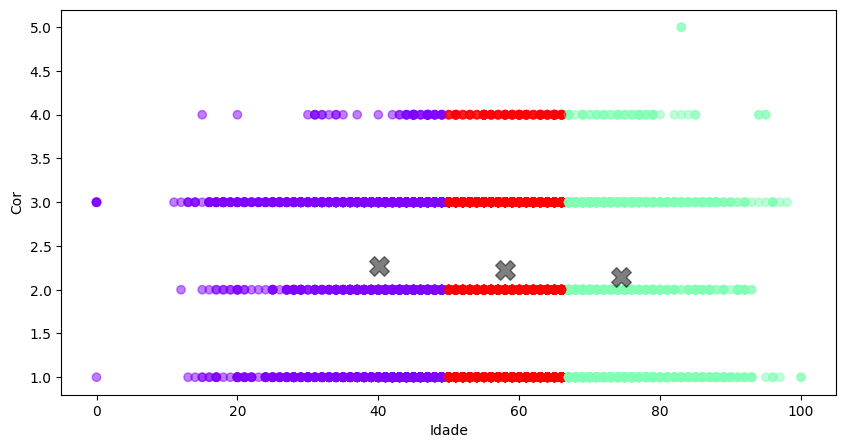

In [24]:
executar_kmeans(dados_fase_1[['IDADE_ANOS', 'RACA_COR']], 3, ['IDADE_ANOS', 'RACA_COR'])

##### 2.4 - KMeans com escalonamento das variáveis

Padronização de `IDADE_ANOS` e `RACA_COR` e novo ajuste do `KMeans` para reduzir o impacto da diferença de escala.


##### GRUPOS #####
1    1617
7    1591
3    1331
0    1285
2     981
4     973
6     660
5     599
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[-0.40964939 -1.31341079]
 [ 0.37750375  0.90983598]
 [ 0.21490433 -0.23448221]
 [ 0.95499166 -1.31341079]
 [ 1.40457607  0.72025315]
 [-1.74910315  0.8696634 ]
 [-1.47065062 -0.67749682]
 [-0.57463825  0.89259466]]
##################
 
##### SILHOUETE SCORE #####
0.46535160727462194
##################


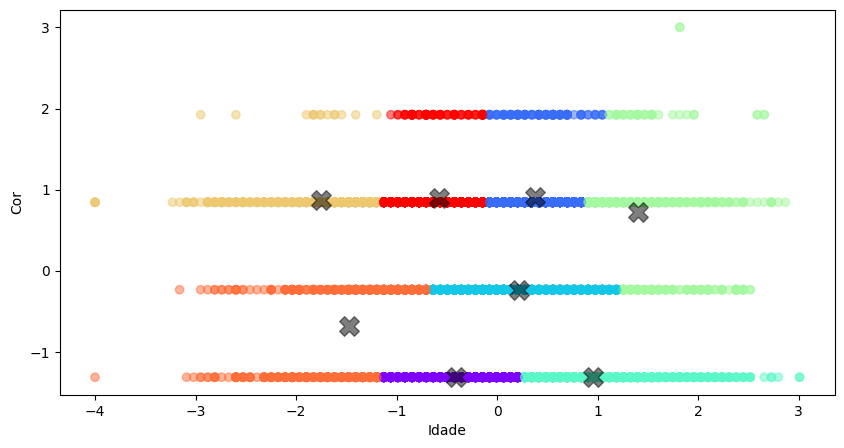

In [25]:
from sklearn.preprocessing import MinMaxScaler


scaler = StandardScaler() 
#scaler = MinMaxScaler() 
colunas = ['IDADE_ANOS','RACA_COR']
scaler.fit(dados_fase_1[colunas])
dados_Escalonados = scaler.transform(dados_fase_1[colunas])
dados_Escalonados = dados_Escalonados_df = pd.DataFrame(
    dados_Escalonados,
    columns=colunas
)

executar_kmeans(dados_Escalonados, 8, colunas)

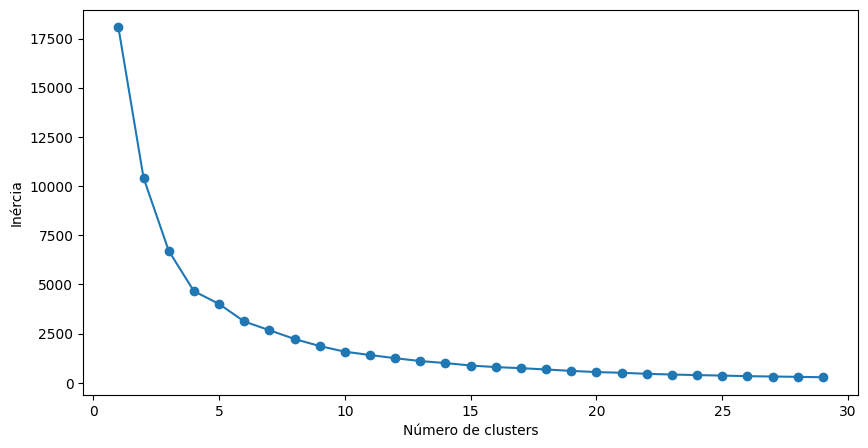

In [26]:
aplicar_elbow(dados_Escalonados, colunas, 30)

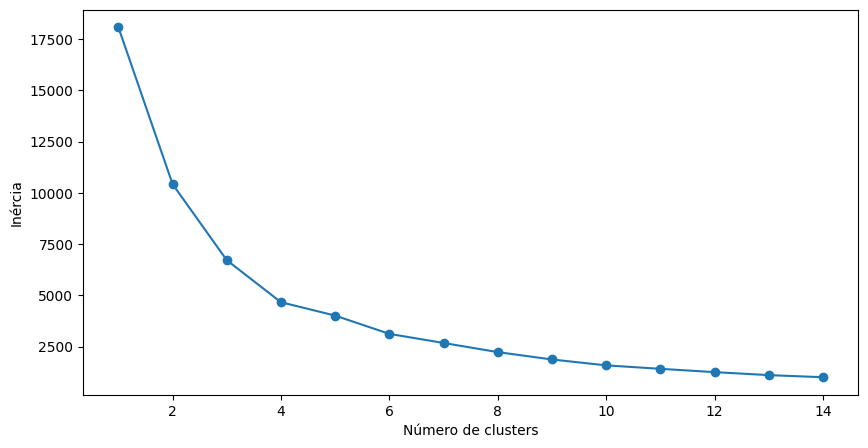

In [27]:
aplicar_elbow(dados_Escalonados, colunas, 15)

##### GRUPOS #####
1    2850
3    2598
2    2304
0    1285
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[-4.09649390e-01 -1.31341079e+00  2.22044605e-15]
 [-1.02897953e+00  5.24174937e-01  6.34807018e+00]
 [ 1.14485521e+00 -4.54576146e-01  3.42230903e+00]
 [ 3.16106508e-01  4.77743545e-01  1.37759815e+00]]
##################
 
##### SILHOUETE SCORE #####
0.2557481053052979
##################


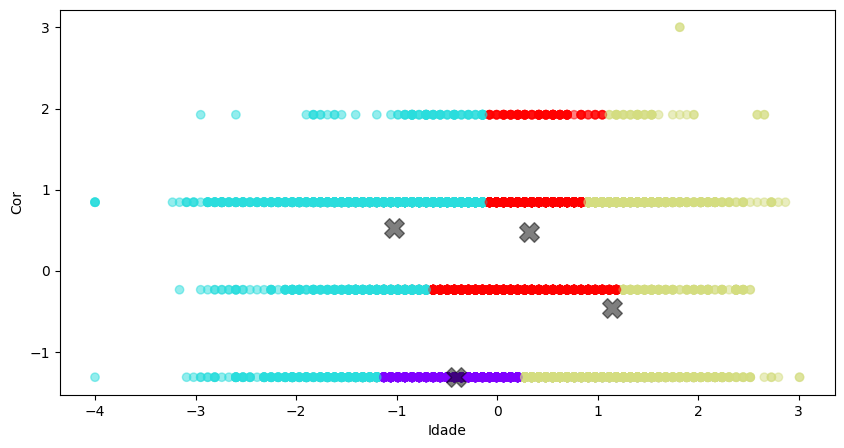

In [28]:
executar_kmeans(dados_Escalonados, 4, colunas)

##### GRUPOS #####
4    2595
2    2579
0    1556
3    1331
1     976
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[-0.64137229 -1.31341079  0.17416452]
 [ 1.40347546  0.72395127  2.00307377]
 [-0.95425197  0.7172675   1.        ]
 [ 0.95499166 -1.31341079  2.        ]
 [ 0.31526211  0.47607229  3.        ]]
##################
 
##### SILHOUETE SCORE #####
0.3870687104469097
##################


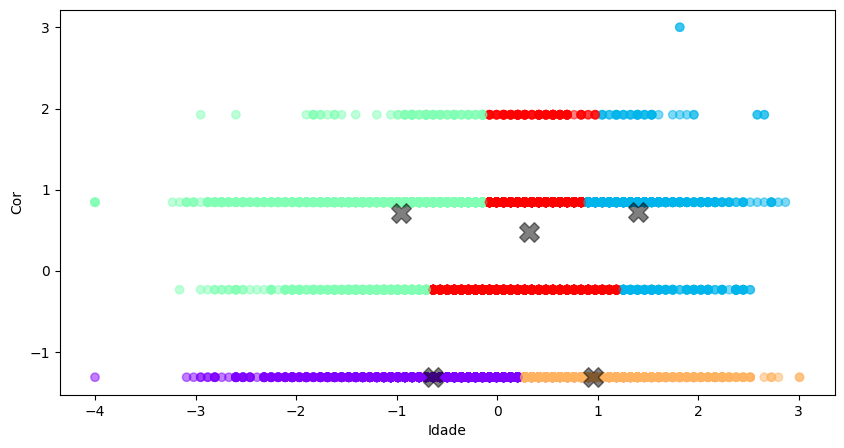

In [29]:
executar_kmeans(dados_Escalonados, 5, colunas)

##### 2.5 - One-hot encoding de raça/cor e experimentos com PCA

Transformação de `RACA_COR` em variáveis dummies, aplicação de `PCA` e execução de novos testes de clusterização para verificar se a representação categórica e a redução de dimensionalidade melhoram a separação entre grupos.

In [30]:
dados_fase_1["RACA_COR"] = dados_fase_1["RACA_COR"]
dummies = pd.get_dummies(dados_fase_1["RACA_COR"], prefix="categ_cor", dtype=int)
dados_fase_1 = pd.concat([dados_fase_1, dummies], axis=1)
colunasComOneHot = ["IDADE_ANOS","categ_cor_1","categ_cor_2","categ_cor_3","categ_cor_4","categ_cor_5"]
dados_fase_1.info()

<class 'pandas.DataFrame'>
Index: 9037 entries, 3042 to 925237
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   UTI_MES_TO          9037 non-null   int64   
 1   DIAS_PERM           9037 non-null   int64   
 2   QT_DIARIAS          9037 non-null   int64   
 3   DIAR_ACOM           9037 non-null   int64   
 4   IDADE_ANOS          9037 non-null   int64   
 5   COMPLEX             9037 non-null   str     
 6   MES_CMPT            9037 non-null   int64   
 7   RACA_COR            9037 non-null   int64   
 8   MORTE               9037 non-null   int64   
 9   CANCER_MAMA_NIVEL   9037 non-null   int64   
 10  PROC_REA            9037 non-null   int64   
 11  MUNIC_RES           9037 non-null   str     
 12  MUNIC_MOV           9037 non-null   str     
 13  DIAG_PRINC_INT      9037 non-null   int64   
 14  COMPLEX_INT         9037 non-null   int64   
 15  houve_deslocamento  9037 non-null   int64   
 16 

##### GRUPOS #####
1    2428
4    1977
6    1290
0     821
2     784
5     776
7     739
3     222
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[-1.41403379 -0.80485068]
 [ 1.19855631 -0.32934405]
 [-0.57899743  2.45638125]
 [-0.5595603   0.64538443]
 [ 1.40350623 -0.21151066]
 [-1.72239175 -0.98213723]
 [-1.57370113 -0.89664942]
 [-0.78362378  2.33873389]]
##################
 
##### SILHOUETE SCORE #####
0.5565971877052175
##################


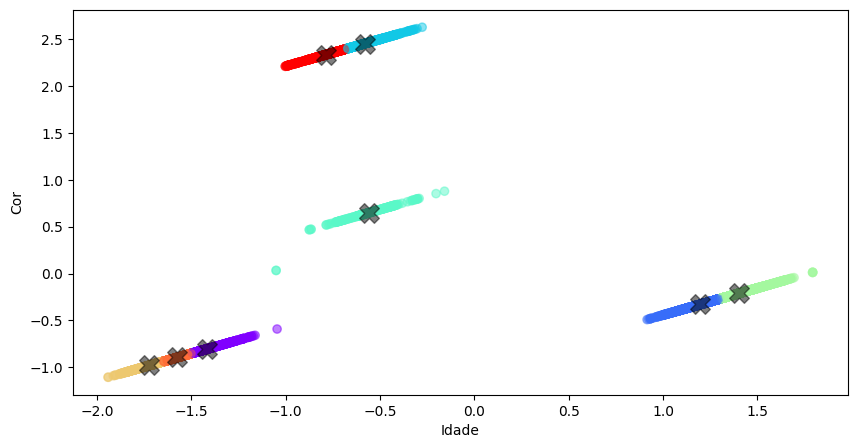

In [31]:
colunasComPca = ["col1", "col2"]
def pca(dados, n, columns, scaler):    
    pipeline_pca = Pipeline([
        ("scaler", scaler),
        ("pca", PCA(n_components=n))
    ])
    return pipeline_pca.fit_transform(dados[columns])

dados_pca = pd.DataFrame(
    pca(dados_fase_1, 2, colunasComOneHot, StandardScaler()),
    columns = colunasComPca
)
 
executar_kmeans(dados_pca, 8, colunasComPca)

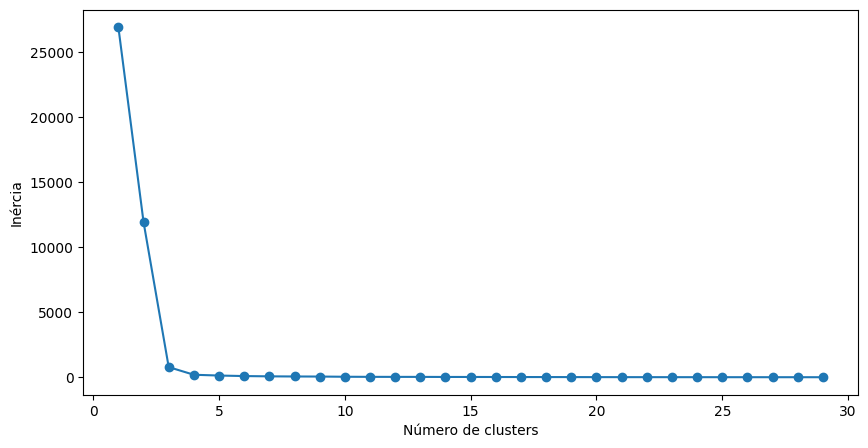

In [32]:
aplicar_elbow(dados_pca, colunasComPca, 30)

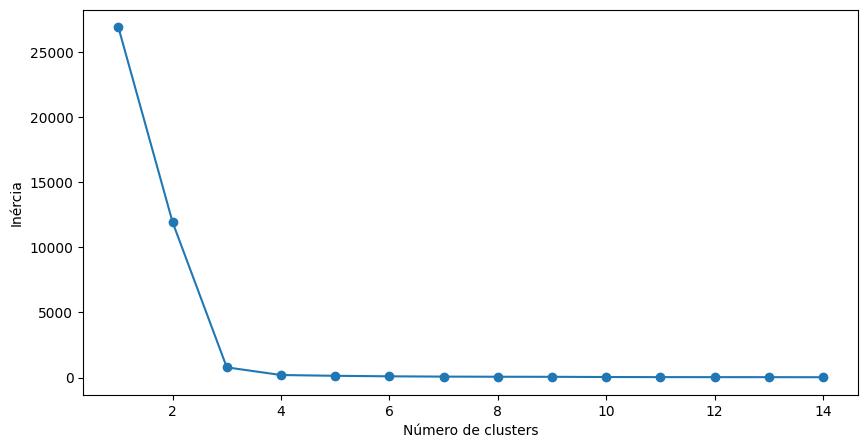

In [33]:
aplicar_elbow(dados_pca, colunasComPca, 15)

##### GRUPOS #####
2    5411
1    2805
0     821
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[-1.41403379e+00 -8.04850681e-01 -1.33226763e-15]
 [-1.40668393e+00 -6.79115519e-02  5.98680927e+00]
 [ 9.43757192e-01  1.57322918e-01  2.32304565e+00]]
##################
 
##### SILHOUETE SCORE #####
0.2780466591290812
##################


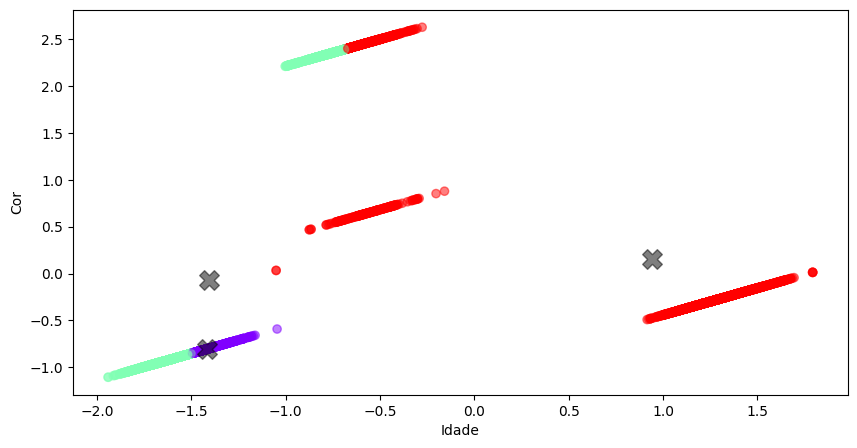

In [34]:
executar_kmeans(dados_pca, 3, colunasComPca)

##### GRUPOS #####
1    4405
3    2068
2    1743
0     821
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[-1.41403379e+00 -8.04850681e-01 -8.88178420e-16]
 [ 1.29053951e+00 -2.76459462e-01  2.00000000e+00]
 [-6.62738718e-01  2.17862106e+00  1.57601836e+00]
 [-1.62898995e+00 -9.27828901e-01  1.00096712e+00]]
##################
 
##### SILHOUETE SCORE #####
0.7763174679083426
##################


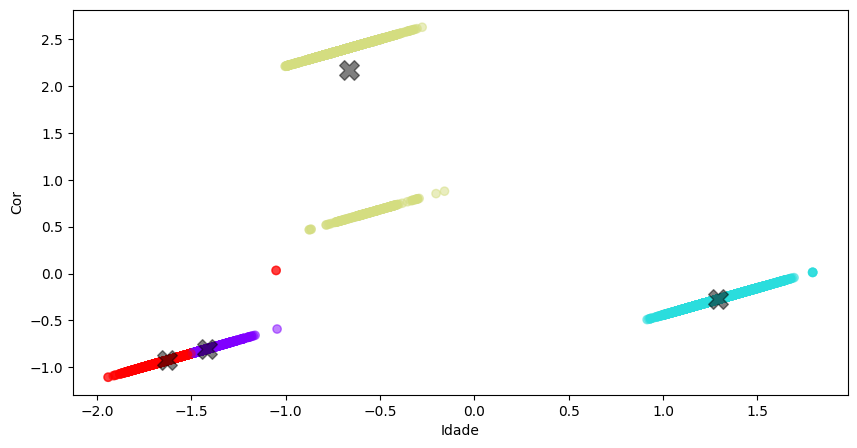

In [35]:
executar_kmeans(dados_pca, 4, colunasComPca)

In [36]:
def melhor_pca(dados, columns, scaler):  

    for n in range(1, len(columns) + 1):
        pipeline_pca = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=n))
        ])

        dados_pca = pipeline_pca.fit_transform(dados[columns])

        pca = pipeline_pca.named_steps["pca"]

        variancia_acumulada = pca.explained_variance_ratio_.sum()

        print(f"n_componentes {n} variancia_acumulada {variancia_acumulada}") 
        
melhor_pca(dados_fase_1, colunasComOneHot, StandardScaler())

n_componentes 1 variancia_acumulada 0.2831717999711695
n_componentes 2 variancia_acumulada 0.49619598583476643
n_componentes 3 variancia_acumulada 0.6708357805180301
n_componentes 4 variancia_acumulada 0.8397044978601436
n_componentes 5 variancia_acumulada 1.0
n_componentes 6 variancia_acumulada 1.0


In [37]:
colunasComPca = ["col1", "col2","col3", "col4"]
dados_pca = pd.DataFrame(
    pca(dados_fase_1, 4, colunasComOneHot, StandardScaler()),
    columns = colunasComPca
)
 
executar_kmeans(dados_pca, 8, colunasComPca, exibir_grafico=False)

##### GRUPOS #####
1    2428
4    1977
6    1554
0    1333
2     784
7     739
3     220
5       2
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[-1.45759496e+00 -8.29895629e-01 -6.07997797e-01 -3.61349737e-01]
 [ 1.19855631e+00 -3.29344051e-01  2.86755061e-01  3.48899095e-01]
 [-5.78997433e-01  2.45638125e+00 -6.49476932e-01 -1.17916724e-01]
 [-5.55098297e-01  6.50951192e-01  5.54978729e+00 -2.85022131e+00]
 [ 1.40350623e+00 -2.11510660e-01 -4.11473215e-01 -2.91123496e-01]
 [-1.05038056e+00  3.30404221e-02  1.85449420e+01  5.41591043e+01]
 [-1.66319055e+00 -9.48100247e-01  9.24302013e-02  2.80689203e-01]
 [-7.83623779e-01  2.33873389e+00  4.76490061e-02  5.21095422e-01]]
##################
 
##### SILHOUETE SCORE #####
0.5657896968861856
##################


In [38]:
colunasComPca = ["col1", "col2","col3", "col4","col5"]
dados_pca = pd.DataFrame(
    pca(dados_fase_1, 5, colunasComOneHot, StandardScaler()),
    columns = colunasComPca
)
 
executar_kmeans(dados_pca, 8, colunasComPca, exibir_grafico=False)

##### GRUPOS #####
5    2213
1    2192
6    1554
0    1333
3     784
7     739
4     220
2       2
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[-1.45759496e+00 -8.29895629e-01 -6.07997797e-01 -3.61349737e-01
  -7.68796401e-01]
 [ 1.18801114e+00 -3.35406867e-01  3.22680607e-01  3.81829818e-01
   7.19216654e-01]
 [-1.05038056e+00  3.30404221e-02  1.85449420e+01  5.41591043e+01
  -3.52735506e+01]
 [-5.78997433e-01  2.45638125e+00 -6.49476932e-01 -1.17916724e-01
  -4.46514486e-01]
 [-5.55098297e-01  6.50951192e-01  5.54978729e+00 -2.85022131e+00
  -1.43885585e+00]
 [ 1.39209495e+00 -2.18071433e-01 -3.72596995e-01 -2.55488074e-01
  -5.48516946e-01]
 [-1.66319055e+00 -9.48100247e-01  9.24302013e-02  2.80689203e-01
   5.08328166e-01]
 [-7.83623779e-01  2.33873389e+00  4.76490061e-02  5.21095422e-01
   8.24589274e-01]]
##################
 
##### SILHOUETE SCORE #####
0.5679619163041165
##################


In [39]:
colunasComPca = ["col1", "col2","col3", "col4","col5", "col6"]
dados_pca = pd.DataFrame(
    pca(dados_fase_1, 6, colunasComOneHot, StandardScaler()),
    columns = colunasComPca
)
 
executar_kmeans(dados_pca, 8, colunasComPca, exibir_grafico=False)

##### GRUPOS #####
5    2213
1    2192
6    1554
0    1333
3     784
7     739
4     220
2       2
Name: count, dtype: int64
##################
 
##### CENTROIDES #####
[[-1.45759496e+00 -8.29895629e-01 -6.07997797e-01 -3.61349737e-01
  -7.68796401e-01 -1.18710419e-16]
 [ 1.18801114e+00 -3.35406867e-01  3.22680607e-01  3.81829818e-01
   7.19216654e-01  8.05161028e-16]
 [-1.05038056e+00  3.30404221e-02  1.85449420e+01  5.41591043e+01
  -3.52735506e+01  1.73260397e-16]
 [-5.78997433e-01  2.45638125e+00 -6.49476932e-01 -1.17916724e-01
  -4.46514486e-01 -1.27764157e-15]
 [-5.55098297e-01  6.50951192e-01  5.54978729e+00 -2.85022131e+00
  -1.43885585e+00 -5.41900623e-15]
 [ 1.39209495e+00 -2.18071433e-01 -3.72596995e-01 -2.55488074e-01
  -5.48516946e-01  6.79880854e-16]
 [-1.66319055e+00 -9.48100247e-01  9.24302013e-02  2.80689203e-01
   5.08328166e-01 -1.47679868e-17]
 [-7.83623779e-01  2.33873389e+00  4.76490061e-02  5.21095422e-01
   8.24589274e-01 -1.14487264e-15]]
##################
 
#

#### Item 3 - Agrupamento com DBSCAN

**Neste passo vamos:**

- **3.1 - Ajustar o DBSCAN** sobre `IDADE_ANOS` e `RACA_COR` para detectar regiões densas sem fixar previamente o número de grupos.
- **3.2 - Visualizar os rótulos gerados** para observar como o algoritmo organiza os registros.
- **3.3 - Comparar o resultado com KMeans** usando a métrica de silhouette como referência complementar.


##### 3.1 - Ajuste do DBSCAN para idade e raça/cor

Aplicação do `DBSCAN` com `eps=10` e `min_samples=8` para identificar agrupamentos por densidade sem fixar previamente o número de clusters.


In [40]:
#Criando o modelo:
dbscan = DBSCAN(eps=10, min_samples=8)
#Ajustando aos dados
dbscan.fit(dados_fase_1[['IDADE_ANOS','RACA_COR']])

dbscan_labels = dbscan.labels_
dbscan_labels

array([0, 0, 0, ..., 0, 0, 0], shape=(9037,))

##### 3.2 - Visualização dos agrupamentos identificados

Plotagem dos rótulos gerados pelo `DBSCAN` para observar a organização espacial dos registros.


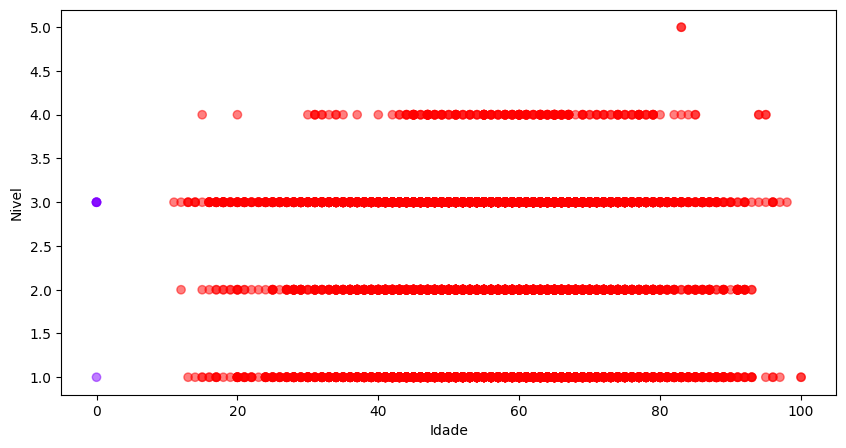

In [41]:
plt.scatter(dados_fase_1[['IDADE_ANOS']],dados_fase_1['RACA_COR'], c=dbscan_labels, alpha=0.5, cmap='rainbow')
plt.xlabel('Idade')
plt.ylabel('Nivel')
plt.show()

##### 3.3 - Avaliação comparativa com silhouette score

Cálculo do `silhouette score` para comparar o resultado do `DBSCAN` com o desempenho do `KMeans`.


In [42]:
silhouette_score(dados_fase_1[['IDADE_ANOS','RACA_COR']], dbscan_labels)

0.6841743933464081

#### Conclusão da Parte 4

A análise exploratória confirmou que a base possui **9.037 registros** e concentração mais forte de casos em faixas etárias adultas e idosas. No entanto, os experimentos de agrupamento mostraram que o uso conjunto de atributos pessoais mais simples, como `IDADE_ANOS` e `RACA_COR`, **não foi suficiente para formar grupos semanticamente ricos ou claramente interpretáveis do ponto de vista do problema de negócio**.

Embora o **KMeans** tenha apresentado o melhor resultado quantitativo entre os testes executados, com **silhouette score de 0,7763** na configuração com `one-hot encoding` e `PCA`, a leitura dos agrupamentos indica que a separação ocorreu **quase integralmente em função da idade**. Em outras palavras, o algoritmo encontrou divisões tecnicamente válidas no espaço matemático dos dados, mas essas divisões ficaram pouco informativas quando observadas como perfis pessoais mais amplos, já que a variável `RACA_COR` teve contribuição limitada na definição dos clusters.

No **DBSCAN**, o resultado de **0,6842** reforça a mesma percepção. Mesmo identificando regiões densas com desempenho razoável, o método não revelou uma estrutura de agrupamento substancialmente diferente nem evidências de perfis pessoais mais complexos. Assim, tanto no `KMeans` quanto no `DBSCAN`, os grupos encontrados ficaram dominados pela distribuição etária, o que reduz o valor analítico da segmentação quando o objetivo é compreender relações mais profundas entre características associadas ao câncer de mama.

**Dessa forma, a principal conclusão não é apenas qual algoritmo teve melhor métrica, mas sim que as variáveis pessoais utilizadas nesta etapa não sustentaram, sozinhas, uma segmentação exploratória suficientemente significativa.** Para obter uma análise realmente efetiva com as mesmas técnicas de agrupamento, seria importante contar com o **auxílio de um especialista do domínio**, capaz de orientar melhor a seleção de atributos, validar combinações clinicamente relevantes e indicar variáveis com maior capacidade de diferenciar perfis de pacientes de maneira útil e interpretável.
